## Gerekli Kütüphaneleri İçe Aktarma

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

## Veri Yolu (Colab / Google Drive)

Colab'da çalışıyorsan aşağıdaki üç satırın başındaki `#` işaretlerini kaldır ve `VERI_KLASORU`'nu dosyanın Drive'daki klasörüne göre düzenle.

In [1]:
# --- GOOGLE COLAB + DRIVE KULLANIYORSAN bu üç satırın başındaki # işaretlerini sil: ---
# from google.colab import drive
# drive.mount('/content/drive')
# VERI_KLASORU = "/content/drive/MyDrive/SoftITO"   # csv'nin Drive'daki klasörü

# Bilgisayarda ya da dosya notebook ile aynı klasördeyse:
VERI_KLASORU = "."


## 1. Veri Setini Keşfetme

In [3]:
df = pd.read_csv(f"{VERI_KLASORU}/global_ai_jobs.csv")
print("Boyut:", df.shape)
print("Eksik değer:", df.isnull().sum().sum(), "| Duplicate:", df.duplicated().sum())
df.head(3)

Boyut: (90000, 35)


Eksik değer: 0 | Duplicate: 0


,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61


In [4]:
# Hedef değişken: experience_level
print(df["experience_level"].value_counts())
print()
print("Sınıflar neredeyse mükemmel dengeli (%25'er) - önceki dersteki diyabet verisinin tam tersi!")
print("Bu sefer accuracy metriği tek başına bile anlamlı olacak.")

experience_level
Senior    22680
Lead      22556
Mid       22459
Entry     22305
Name: count, dtype: int64

Sınıflar neredeyse mükemmel dengeli (%25'er) - önceki dersteki diyabet verisinin tam tersi!
Bu sefer accuracy metriği tek başına bile anlamlı olacak.


## 2. ⭐ Veri Sızıntısı Tespiti

Modele özellik seçmeden önce şüpheli bir sütunu kontrol edelim: `experience_years`.
Tecrübe *seviyesi*ni tahmin ederken tecrübe *yılını* kullanmak mantıklı mı?

In [5]:
# experience_level ile experience_years ilişkisi
print(df.groupby("experience_level")["experience_years"].agg(["min", "max"]))

                  min  max
experience_level          
Entry               0    1
Lead               12   19
Mid                 2    5
Senior              6   11


**Tuzak ortaya çıktı:** Yıl aralıkları hiç örtüşmüyor — Entry: 0-1, Mid: 2-5, Senior: 6-11,
Lead: 12-19. Yani `experience_level` doğrudan `experience_years`'tan **türetilmiş**. Bu sütunu
modele koyarsak model hiçbir örüntü öğrenmez, cevabı kopya çeker ve %100 başarıyla bizi kandırır.
Buna **veri sızıntısı (data leakage)** denir — 08. pratikte `Sira` sütununu dışlamıştık, aynı ilke.

`experience_years`'ı (ve bilgi taşımayan `id` ile `year`'ı) özellik listesinden **çıkarıyoruz**.
Model, seviyeyi ilanın *diğer* özelliklerinden (maaş, mülakat turu, şirket bilgileri...) öğrenmek
zorunda kalacak — gerçek ve dürüst bir tahmin problemi.

## 3. ⭐ SVM'in Ölçeklenme Sınırı ve Örneklem

SVM'in eğitim süresi örnek sayısıyla **karesel-kübik** büyür; 90.000 satır + GridSearchCV
saatler sürer. Gerçek hayatta bu durumda ya LinearSVC/SGD gibi ölçeklenebilir alternatifler
kullanılır ya da **katmanlı (stratified) örneklem** alınır. Biz dersle aynı araçları (SVC +
GridSearchCV) kullanabilmek için ikinci yolu seçiyoruz: sınıf oranlarını koruyan 8.000 satırlık örneklem.

In [6]:
# Katmanlı örneklem: her sınıftan 2.000'er, toplam 8.000 satır
orneklem = df.groupby("experience_level").sample(n=2000, random_state=42).reset_index(drop=True)

print("Örneklem boyutu:", orneklem.shape)
print(orneklem["experience_level"].value_counts())

Örneklem boyutu: (8000, 35)
experience_level
Entry     2000
Lead      2000
Mid       2000
Senior    2000
Name: count, dtype: int64


## 4. Veri Ön İşleme

Dersteki sırayla: kategorik kodlama → özellik/hedef ayrımı → train/test → ölçekleme.

In [7]:
# Özellik seçimi: sızıntı yapan ve bilgi taşımayan sütunlar HARİÇ
haric = ["experience_level", "experience_years", "id", "year"]
kategorik = ["country", "job_role", "ai_specialization", "education_required",
             "industry", "company_size", "work_mode"]
sayisal = [c for c in orneklem.columns if c not in haric + kategorik]

print(f"{len(sayisal)} sayısal + {len(kategorik)} kategorik özellik kullanılacak")

# Kategorikleri one-hot (get_dummies) ile kodluyoruz
X = pd.get_dummies(orneklem[sayisal + kategorik], columns=kategorik, drop_first=True)
y = orneklem["experience_level"]

print("Kodlama sonrası özellik sayısı:", X.shape[1])

24 sayısal + 7 kategorik özellik kullanılacak
Kodlama sonrası özellik sayısı: 68


In [8]:
# Train/test ayrımı (dengeli olsa da alışkanlık olarak stratify kullanıyoruz)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ölçekleme: fit SADECE eğitim verisine (data leakage önlemi - artık refleks oldu!)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Eğitim: {X_train_s.shape} | Test: {X_test_s.shape}")

Eğitim: (6400, 68) | Test: (1600, 68)


## 5. Üç Kernel ile SVM (Dersteki Karşılaştırma)

Doğrusal, RBF ve polinom kernel'lerini varsayılan ayarlarla eğitip karşılaştırıyoruz.

In [9]:
kernel_sonuclari = {}
for kernel in ["linear", "rbf", "poly"]:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    kernel_sonuclari[kernel] = acc
    print(f"{kernel:<8} kernel -> Test doğruluğu: {acc:.4f}")

print(f"\n(4 sınıflı dengeli problemde rastgele tahmin taban çizgisi: 0.25)")

linear   kernel -> Test doğruluğu: 0.8588


rbf      kernel -> Test doğruluğu: 0.8300


poly     kernel -> Test doğruluğu: 0.7619

(4 sınıflı dengeli problemde rastgele tahmin taban çizgisi: 0.25)


## 6. GridSearchCV ile Hiperparametre Optimizasyonu

Dersteki gibi C/gamma taraması — ama kernel seçimini de aramaya dahil ediyoruz, çünkü ilk denemede
linear kernel'in RBF'i geçmesi "acaba?" dedirtti. Karar veriye bırakılır, varsayıma değil.

In [10]:
param_grid = {
    "kernel": ["linear", "rbf"],   # ikisini de yarıştırıyoruz - varsayılan denemede linear şaşırtıcı iyi çıkmıştı
    "C": [1, 10],
    "gamma": ["scale", 0.01],      # linear kernel gamma'yı yok sayar, sorun değil
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=3,
                    scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_train_s, y_train)

print("\nEn iyi parametreler:", grid.best_params_)
print(f"En iyi CV doğruluğu : {grid.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits



En iyi parametreler: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
En iyi CV doğruluğu : 0.8613


In [11]:
# En iyi modelle test seti değerlendirmesi
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_s)

print(f"Test doğruluğu: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

Test doğruluğu: 0.8588

              precision    recall  f1-score   support

       Entry       0.99      0.97      0.98       400
        Lead       0.84      0.81      0.83       400
         Mid       0.88      0.88      0.88       400
      Senior       0.73      0.77      0.75       400

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600



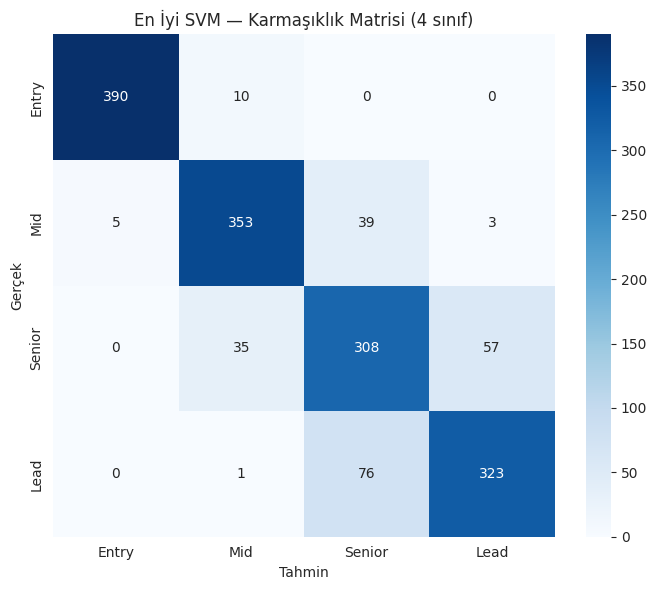

In [12]:
# 4x4 karmaşıklık matrisi
siralama = ["Entry", "Mid", "Senior", "Lead"]   # kariyer sırasına göre
cm = confusion_matrix(y_test, y_pred, labels=siralama)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=siralama, yticklabels=siralama)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("En İyi SVM — Karmaşıklık Matrisi (4 sınıf)")
plt.tight_layout()
plt.show()

**Matrisin okunması:** Hatalar rastgele dağılmıyor — model en çok **komşu seviyeleri**
karıştırıyor (Mid↔Senior gibi). Bu mantıklı: bir Mid ilanıyla Senior ilanının maaş/koşul profilleri
birbirine yakınken, Entry ile Lead'i ayırt etmek çok daha kolay. Modelin hataları bile problemin
doğasını yansıtıyor.

## 7. Hangi Özellikler İşe Yaradı? (Basit Kontrol)

SVM (RBF kernel) katsayı vermez; ama en güçlü sinyalin maaş olduğunu basit bir tabloyla doğrulayabiliriz.

In [13]:
print("Seviyeye göre örneklem ortalamaları:")
print(orneklem.groupby("experience_level")[["salary_usd", "bonus_usd", "interview_rounds"]]
      .mean().round(0).loc[siralama])

Seviyeye göre örneklem ortalamaları:
                  salary_usd  bonus_usd  interview_rounds
experience_level                                         
Entry                62016.0     8370.0               4.0
Mid                  77469.0    10488.0               5.0
Senior              105138.0    14138.0               5.0
Lead                143209.0    19219.0               5.0


## 8. Özet — Bu Pratikte Öğrendiklerim

1. ⭐ **Veri sızıntısı yakalandı:** `experience_years` hedefi birebir belirliyordu → dışlandı.
   Sızıntılı model %100 başarı gösterip hiçbir şey öğrenmemiş olurdu
2. ⭐ **SVM'in ölçek sınırı yaşandı:** 90 bin satır SVC + GridSearch için pratik değil →
   sınıf oranlarını koruyan katmanlı örneklemle (8.000) çalışıldı; alternatiflerin
   (LinearSVC, SGDClassifier) ne zaman gerektiği öğrenildi
3. **Üç kernel karşılaştırıldı** — dengeli 4 sınıflı problemde taban çizgisi %25'ti,
   modeller bunun çok üzerine çıktı
4. **GridSearchCV** ile C/gamma taraması yapıldı (dersteki akışın aynısı)
5. ⭐ **"Karmaşık olan her zaman kazanmaz":** linear kernel, RBF ve polinomu geçti — sınıflar
   büyük ölçüde (maaş ekseninde) doğrusal ayrılabiliyor; kernel seçimi denenerek yapılır
6. **Karmaşıklık matrisi yorumlandı:** hatalar komşu seviyeler arasında yoğunlaştı (özellikle
   Senior↔Lead ve Senior↔Mid) — modelin hataları bile anlamlı
7. Kategorik kodlama (`get_dummies`) + ölçekleme + stratify artık standart refleks

**Sonraki adım fikirleri:** LinearSVC ile 90 bin satırın tamamını kullanmak, RandomForest ile
karşılaştırıp özellik önemlerini görmek.